<a href="https://colab.research.google.com/github/useDeep/learn_pytorch/blob/main/06_pytorch_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06. PyTorch Transfer Learning

Pretrained models are also called as foundation models

In [27]:
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.11.0+cu128
0.26.0+cu128


Import the code from Chapter 05

In [28]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

In [29]:
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 1. Get data

We need the pizza, suchi and steak data to build a transfer learning model.

In [30]:
import os
import zipfile
from pathlib import Path
import requests

data_path= Path("data/")
image_path= data_path / "pizza_steak_sushi"

if image_path.is_dir():
  print(f"{image_path} directory exists, skipping downloading")
else:
  print(f"Didn't find the {image_path}, downloading it...")
  image_path.mkdir(parents=True, exist_ok= True)

  with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
    req= requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    f.write(req.content)

  with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    zip_ref.extractall(image_path)

  os.remove(data_path / "pizza_steak_sushi.zip")

data/pizza_steak_sushi directory exists, skipping downloading


In [31]:
train_dir= image_path / "train"
test_dir= image_path / "test"

## 2. Create Datasets and DataLoaders

With `torchvision 0.13+`, there are two ways to transform the data:
1. Manually created transforms
2. Automatically created transforms [0.13+]- the transforms for the data are defined by the upstream model we'd like to use.

**NOTE**: when using pretrained model, it's important that the data (custom data) that we pass through it is transformed the same way that the data the model was trained on.

### 2.1 Creating a transform for `torchvision.models` (manual creation)

`torchvision.models` contain pretrained models (models ready for transfer learning) right within `torchvision`.

In [32]:
from torchvision import transforms

normalize= transforms.Normalize(mean= [0.485, 0.456, 0.406],
                                std= [0.229, 0.224, 0.225])     # from torchvision 0.12 documentation

manual_transforms= transforms.Compose([
    transforms.Resize((224, 224)),    # resize images to 224 * 224 (height * width)
    transforms.ToTensor(),    # get images into range [0, 1]
    normalize     # make sure images have same distribution as ImageNet (pretrained model)
])

In [33]:
from going_modular.going_modular import data_setup

train_dataloader, test_dataloader, class_names= data_setup.create_dataloaders(train_dir= train_dir,
                                                                              test_dir= test_dir,
                                                                              transform= manual_transforms,
                                                                              batch_size= 32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7ba94321a900>,
 ['pizza', 'steak', 'sushi'])

### 2.2 Creating a transform for `torchvision.models` (automatic)

Note: v0.13+ only offers `Multi-weight support API`

In [34]:
# Get a set of pretrained model weights
weights= torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [35]:
# Get the transforms used to create the pretrained weights
auto_transforms= weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [36]:
# Create dataloaders using automatic transforms
train_dataloader, test_dataloader, class_names= data_setup.create_dataloaders(train_dir= train_dir,
                                                                              test_dir= test_dir,
                                                                              transform= auto_transforms,
                                                                              batch_size= 32)

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7ba94371cd70>,
 ['pizza', 'steak', 'sushi'])

## 3.1 Getting and setting up a pretrained model

In [37]:
weights= torchvision.models.EfficientNet_B0_Weights.DEFAULT   # Default is the best available weights

model= torchvision.models.efficientnet_b0(weights= weights)
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [38]:
summary(model)

Layer (type:depth-idx)                                  Param #
EfficientNet                                            --
├─Sequential: 1-1                                       --
│    └─Conv2dNormActivation: 2-1                        --
│    │    └─Conv2d: 3-1                                 864
│    │    └─BatchNorm2d: 3-2                            64
│    │    └─SiLU: 3-3                                   --
│    └─Sequential: 2-2                                  --
│    │    └─MBConv: 3-4                                 1,448
│    └─Sequential: 2-3                                  --
│    │    └─MBConv: 3-5                                 6,004
│    │    └─MBConv: 3-6                                 10,710
│    └─Sequential: 2-4                                  --
│    │    └─MBConv: 3-7                                 15,350
│    │    └─MBConv: 3-8                                 31,290
│    └─Sequential: 2-5                                  --
│    │    └─MBConv: 3-9         

In [39]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

### 3.2 Getting a summary of the model using `torchinfo.summary()`

In [40]:
summary(model= model,
        input_size= (1, 3, 224, 224),   # example of [batch_size, color_channels, height, width]
        col_names= ["input_size", "output_size", "num_params", "trainable"],
        col_width= 20,
        row_settings= ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

### 3.3 Freezing the base model and changing the ouput layer to suit our needs

In [41]:
# Freeze all of the base layers in EffNetB0
for param in model.features.parameters():
  param.requires_grad= False

In [42]:
summary(model= model,
        input_size= (1, 3, 224, 224),   # example of [batch_size, color_channels, height, width]
        col_names= ["input_size", "output_size", "num_params", "trainable"],
        col_width= 20,
        row_settings= ["var_names"])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [43]:
# Update the classifier

torch.manual_seed(77)
torch.cuda.manual_seed(77)

model.classifier= nn.Sequential(
    nn.Dropout(p= 0.2, inplace= True),
    nn.Linear(in_features= 1280,
              out_features= len(class_names))
)

model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=3, bias=True)
)

## 4. Train the model

In [44]:
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params= model.parameters(),
                            lr= 0.001)

In [45]:
from going_modular.going_modular import engine

torch.manual_seed(77)
torch.cuda.manual_seed(77)

from timeit import default_timer as timer
start_time= timer()

results= engine.train(model= model,
                      train_dataloader= train_dataloader,
                      test_dataloader= test_dataloader,
                      optimizer= optimizer,
                      loss_fn= loss_fn,
                      epochs= 5,
                      device= device)

end_time= timer()
print(f"[INFO] Total training time: {end_time - start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0657 | train_acc: 0.4336 | test_loss: 0.8743 | test_acc: 0.6515
Epoch: 2 | train_loss: 0.8912 | train_acc: 0.6719 | test_loss: 0.7571 | test_acc: 0.7945
Epoch: 3 | train_loss: 0.7877 | train_acc: 0.7617 | test_loss: 0.6457 | test_acc: 0.8655
Epoch: 4 | train_loss: 0.6368 | train_acc: 0.9102 | test_loss: 0.6416 | test_acc: 0.8655
Epoch: 5 | train_loss: 0.7123 | train_acc: 0.6992 | test_loss: 0.6492 | test_acc: 0.8456
[INFO] Total training time: 18.486 seconds


## 5. Evaluating the model by plotting loss curves

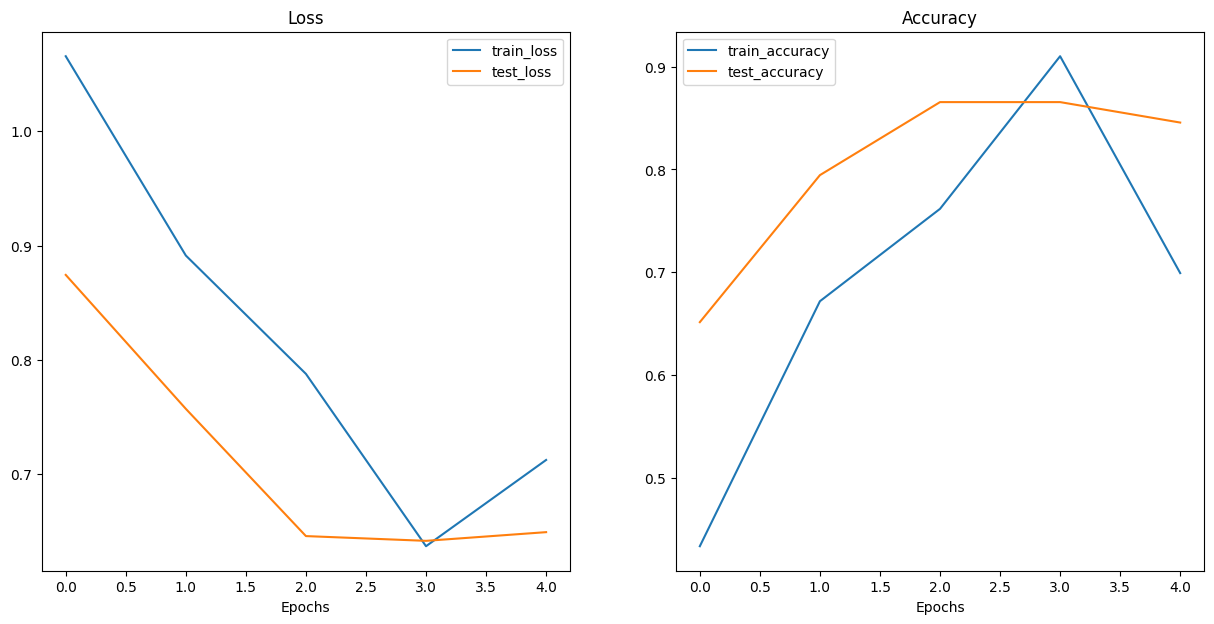

In [46]:
# Get the plot_loss_curves() function from helper_functions.py, download the file if we don't have it
try:
    from helper_functions import plot_loss_curves
except:
    print("[INFO] Couldn't find helper_functions.py, downloading...")
    with open("helper_functions.py", "wb") as f:
        import requests
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
        f.write(request.content)
    from helper_functions import plot_loss_curves

# Plot the loss curves of our model
plot_loss_curves(results)

## 6. Making predictions on images from test set

**Note:** These requirements go for all kinds of data if you're trying to make predictions with a trained model. Data you'd like to predict on should be in the same format as your model was trained on.

To do all of this, we'll create a function `pred_and_plot_image()` to:
  1. Take in a trained model, a list of class names, a filepath to a target image, an image size, a transform and a target device.
  2. Open an image with [`PIL.Image.open()`](https://pillow.readthedocs.io/en/stable/reference/Image.html#PIL.Image.open).
  3. Create a transform for the image (this will default to the `manual_transforms` we created above or it could use a transform generated from `weights.transforms()`).
  4. Make sure the model is on the target device.
  5. Turn on model eval mode with `model.eval()` (this turns off layers like `nn.Dropout()`, so they aren't used for inference) and the inference mode context manager.
  6. Transform the target image with the transform made in step 3 and add an extra batch dimension with `torch.unsqueeze(dim=0)` so our input image has shape `[batch_size, color_channels, height, width]`.
  7. Make a prediction on the image by passing it to the model ensuring it's on the target device.
  8. Convert the model's output logits to prediction probabilities with `torch.softmax()`.
  9. Convert model's prediction probabilities to prediction labels with `torch.argmax()`.
  10. Plot the image with `matplotlib` and set the title to the prediction label from step 9 and prediction probability from step 8.

In [49]:
from PIL import Image
from typing import List, Tuple

# 1. Take in a trained model...
def pred_and_plot(model: torch.nn.Module,
                  image_path: str,
                  class_names: List[str],
                  image_size: Tuple[int, int]= (224, 224),
                  transform: torchvision.transforms= None,
                  device: torch.device= device):
  # 2. Open the image with PIL
  img= Image.open(image_path)

  # 3. Create a transform if one doesn't exist
  if transform is not None:
    image_transform= transform
  else:
    image_transform= transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean= [0.485, 0.456, 0.406],
                                std= [0.229, 0.224, 0.225])
    ])

  # Predict on image
  model.to(device)

  model.eval()
  with torch.inference_mode():
    transformed_image= image_transform(img).unsqueeze(dim= 0)
    target_image_pred= model(transformed_image.to(device))

  target_image_pred_probs= torch.softmax(target_image_pred, dim= 1)

  target_image_pred_label= torch.argmax(target_image_pred_probs, dim= 1)

  plt.figure()
  plt.imshow(img)
  plt.title(f"Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}")
  plt.axis(False)

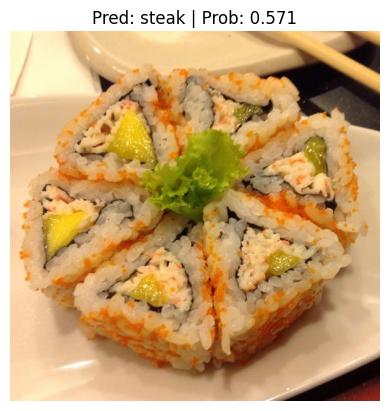

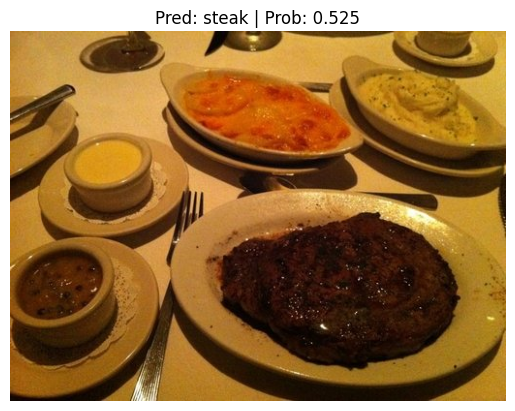

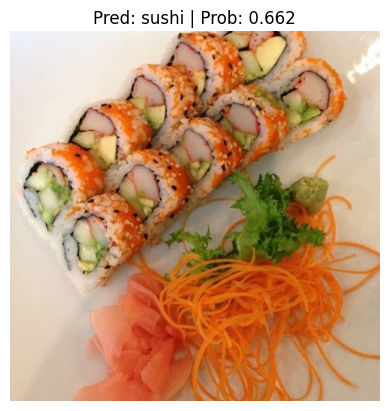

In [53]:
# Get a random list of image paths from test set
import random
num_images_to_plot = 3
test_image_path_list = list(Path(test_dir).glob("*/*.jpg")) # get list all image paths from test data
test_image_path_sample = random.sample(population=test_image_path_list, # go through all of the test image paths
                                       k=num_images_to_plot) # randomly select 'k' image paths to pred and plot

# Make predictions on and plot the images
for image_path in test_image_path_sample:
    pred_and_plot(model=model,
                        image_path=image_path,
                        class_names=class_names,
                        # transform=weights.transforms(), # optionally pass in a specified transform from our pretrained model weights
                        image_size=(224, 224))

data/04-pizza-dad.jpeg already exists, skipping download.


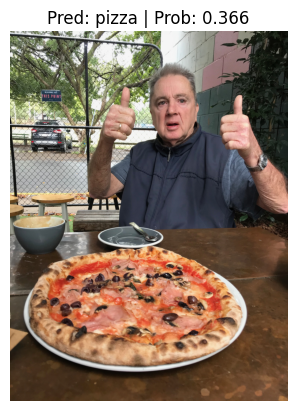

In [55]:
# Download custom image
import requests

# Setup custom image path
custom_image_path = data_path / "04-pizza-dad.jpeg"

# Download the image if it doesn't already exist
if not custom_image_path.is_file():
    with open(custom_image_path, "wb") as f:
        # When downloading from GitHub, need to use the "raw" file link
        request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
        print(f"Downloading {custom_image_path}...")
        f.write(request.content)
else:
    print(f"{custom_image_path} already exists, skipping download.")

# Predict on custom image
pred_and_plot(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)